# Lightweight ASR Pipeline (Kaggle P100) — XLS-R / wav2vec2-large-960h-lv60-self (Local Common Voice v24 en-AU)

This notebook is a **stable, Kaggle P100–friendly** ASR pipeline using **your local Kaggle dataset layout**:

```
mozilla_commonvoice/
  commonvoice-v24_en-AU/
    audio_files/
    commonvoice-v24_en-AU-split.csv
    commonvoice-v24_en-AU.csv
```

## What it does
- Loads your **local** Common Voice v24 en-AU metadata CSV (and split CSV if present)
- Performs **EDA** (durations, transcript length, common words, waveform preview)
- Applies **speech preprocessing** (mono + 16 kHz resample; optional trimming)
- Fine-tunes **`facebook/wav2vec2-large-960h-lv60-self`** (XLS-R style, strong English ASR baseline) on your train split
- Evaluates on validation + test with **WER & CER** (normalized) — targets **WER < 0.05** on en-AU
- Exports **SPSS-like CSV outputs** and an **error analysis** table
- Includes an **inference demo** on a single audio file

## Model choice: why `wav2vec2-large-960h-lv60-self`?
- Pre-trained on 60k hours of unlabelled audio + fine-tuned on LibriSpeech 960h
- Strong English ASR baseline; WER ≈ 1.8 % on LibriSpeech test-clean out of the box
- Fine-tuning on en-AU Common Voice dramatically lowers WER/CER on that accent
- Fits comfortably on a P100 16 GB GPU with fp16
- Model weights ≈ 1.2 GB; total disk usage well inside the 19.5 GB Kaggle output limit

## Kaggle optimisation
- Avoids TorchCodec/FFmpeg issues by decoding audio using **torchaudio.load**
- Filters long clips (default ≤ 15 s)
- Uses fp16 + gradient checkpointing + small batch + grad accumulation
- Saves only a couple of checkpoints + auto-prunes older ones


In [13]:
# 0) Install deps (Kaggle)
# We pin transformers==4.44.2 to stay compatible with Kaggle pre-installs.
# We need `datasets` for the Trainer but do NOT load audio via HF datasets — we decode ourselves.
!pip -q uninstall -y peft || true

!pip -q install \
  "transformers==4.44.2" \
  "accelerate==0.34.2" \
  "datasets==2.20.0" \
  "jiwer==3.0.4" \
  "soundfile==0.12.1"

import os, re, random, json, math, shutil, glob
import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer,
)
from jiwer import wer as jiwer_wer, cer as jiwer_cer

print("torch:", torch.__version__)
print("transformers:", __import__("transformers").__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


torch: 2.9.0+cu126
transformers: 4.44.2
cuda: True
gpu: Tesla P100-PCIE-16GB


In [14]:
# 1) Reproducibility + output
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = "/kaggle/working/xlsr_commonvoice_local"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 2) Locate your dataset folder automatically

We search common Kaggle roots for:
- `commonvoice-v24_en-AU-split.csv` (preferred) or
- `commonvoice-v24_en-AU.csv`


In [15]:
# 2) Find dataset files
def find_first(patterns, roots=("/kaggle/input", "/kaggle/working", "/kaggle")):
    for root in roots:
        for pat in patterns:
            hits = glob.glob(os.path.join(root, "**", pat), recursive=True)
            if hits:
                return hits[0]
    return None

split_csv = find_first(["commonvoice-v24_en-AU-split.csv", "*split*.csv"])
main_csv  = find_first(["commonvoice-v24_en-AU.csv", "*en-AU*.csv"])

print("Found split CSV:", split_csv)
print("Found main  CSV:", main_csv)

if main_csv is None and split_csv is None:
    raise FileNotFoundError("Could not find your Common Voice CSVs under /kaggle/input or /kaggle/working.")

# infer base directory
base_dir = os.path.dirname(split_csv if split_csv else main_csv)
print("Base dir:", base_dir)

# locate audio directory
audio_dir_candidates = [
    os.path.join(base_dir, "audio_files"),
    os.path.join(base_dir, "clips"),
    os.path.join(base_dir, "audio"),
]
audio_dir = next((d for d in audio_dir_candidates if os.path.isdir(d)), None)
print("Audio dir:", audio_dir)
if audio_dir is None:
    raise FileNotFoundError("Could not find audio directory (audio_files/clips/audio).")


Found split CSV: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/commonvoice-v24_en-AU-split.csv
Found main  CSV: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/commonvoice-v24_en-AU.csv
Base dir: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU
Audio dir: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files


## 3) Load CSV(s) and build train/val/test splits

We support multiple formats:
- If the split CSV exists: it should contain a filename/path and a split column.
- If only the main CSV exists: we look for a `split` column; otherwise do an 80/10/10 split.


In [16]:
# 3) Load CSVs — handles BOTH long-split and wide-split CSV formats

def read_csv(path):
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_csv(path, sep=";")

df_main  = read_csv(main_csv) if main_csv else None
df_split = read_csv(split_csv) if split_csv else None

print("main columns:", list(df_main.columns)[:30] if df_main is not None else None)
print("split columns:", list(df_split.columns)[:30] if df_split is not None else None)

TEXT_COL_CANDIDATES  = ["sentence", "text", "transcript", "normalized_text", "utterance"]
AUDIO_COL_CANDIDATES = ["path", "audio_path", "filename", "file", "clip", "audio"]

def pick_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def pick_audio_col(cols):
    for c in AUDIO_COL_CANDIDATES:
        if c in cols:
            return c
    return None

def normalize_split_value(x: str) -> str:
    x = str(x).strip().lower()
    if x in ["train", "tr"]:
        return "train"
    if x in ["valid", "val", "validation", "dev", "devel"]:
        return "val"
    if x in ["test", "te"]:
        return "test"
    return x

audio_col = None

if df_split is not None:
    df = df_split.copy()
    split_col = pick_col(df.columns, ["split", "set", "subset", "partition"])
    if split_col is None:
        for c in df.columns:
            vals = set(str(v).lower() for v in df[c].dropna().unique()[:50])
            if any(v in vals for v in ["train", "validation", "valid", "dev", "test", "val"]):
                split_col = c
                break

    if split_col is None:
        wide_split_cols = []
        for c in df.columns:
            if normalize_split_value(c) in ["train", "val", "test"]:
                wide_split_cols.append(c)

        if len(wide_split_cols) > 0:
            print("Detected WIDE split CSV format. Split columns:", wide_split_cols)
            parts = []
            for c in wide_split_cols:
                tmp = df[[c]].dropna().copy()
                tmp = tmp.rename(columns={c: "path"})
                tmp["split"] = normalize_split_value(c)
                parts.append(tmp)
            df = pd.concat(parts, ignore_index=True)
            split_col = "split"
            audio_col = "path"
        else:
            print("WARNING: Split CSV found but no split column detected. Falling back to main CSV.")
            df = df_main.copy()
            split_col = None
else:
    df = df_main.copy()
    split_col = pick_col(df.columns, ["split", "set", "subset", "partition"])

text_col = pick_col(df.columns, TEXT_COL_CANDIDATES) or (
    pick_col(df_main.columns, TEXT_COL_CANDIDATES) if df_main is not None else None
)
if text_col is None:
    raise ValueError("Could not find transcript column. Try renaming it to 'sentence' or 'text'.")

if audio_col is None:
    audio_col = pick_audio_col(df.columns) or (
        pick_audio_col(df_main.columns) if df_main is not None else None
    )
if audio_col is None:
    raise ValueError("Could not find audio path/filename column. Try 'path' or 'filename'.")

print("Using text column:", text_col)
print("Using audio column:", audio_col)
print("Using split column:", split_col)

if split_col is not None and split_col in df.columns:
    df[split_col] = df[split_col].apply(normalize_split_value)

if df_split is not None and df_main is not None and text_col not in df_split.columns:
    key = audio_col
    if key in df_main.columns and key in df.columns:
        df = df.merge(df_main[[key, text_col]], on=key, how="left")

def to_abs_audio_path(x):
    if pd.isna(x):
        return None
    x = str(x)
    if os.path.isabs(x) and os.path.exists(x):
        return x
    p1 = os.path.join(base_dir, x)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(audio_dir, os.path.basename(x))
    if os.path.exists(p2):
        return p2
    p3 = os.path.join(base_dir, os.path.normpath(x))
    if os.path.exists(p3):
        return p3
    return p2

df["audio_path"] = df[audio_col].apply(to_abs_audio_path)
df["transcript"] = df[text_col].astype(str)

df = df[df["audio_path"].apply(lambda p: isinstance(p, str) and os.path.exists(p))].reset_index(drop=True)

print("Rows with existing audio:", len(df))
df.head()


main columns: ['Unnamed: 0', 'client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'duration_ms']
split columns: ['Unnamed: 0', 'client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'duration_ms']
Using text column: sentence
Using audio column: path
Using split column: None
Rows with existing audio: 55673


,Unnamed: 0,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,duration_ms,audio_path,transcript
0,182,0621ad6390e651ff1e39b23f74e8d624bd8ba0957d6a19...,common_voice_en_30513358.mp3,1f08423cd2153df43fb7c18ddd24edfea7be733046c26d...,Princess Vilas herself also contributed person...,NaN,4,0,teens,male_masculine,Australian English,NaN,en,NaN,7.387500,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Princess Vilas herself also contributed person...
1,725,18bea6bb076cd9638518d93b4af353c3c329d059789e11...,common_voice_en_43618790.mp3,fe3f016c86bea44ab149bc2537de58f16051d8274099a7...,He has also served in the Chamber of Deputies.,NaN,2,0,NaN,NaN,Australian English,NaN,en,NaN,6.307500,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,He has also served in the Chamber of Deputies.
2,885,1db7f61c407a3cdce51e21ae1871ef9ae3ed74d79415ba...,common_voice_en_21099981.mp3,48e620d96dda152eeec48e28f7b0dde29625591bdc44cd...,Most of his subjects were found in Devon and C...,NaN,2,0,thirties,male_masculine,Australian English,NaN,en,NaN,7.949625,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Most of his subjects were found in Devon and C...
3,984,2144a6feb6a906b220cbba00f37b56084bd2d60cce773e...,common_voice_en_39588772.mp3,e3d037f2c263d604b0bb1ef837b1fc7ee7f80d5336031c...,Shots rang out as they fled towards the Austri...,NaN,2,0,NaN,NaN,Australian English,NaN,en,NaN,5.515500,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Shots rang out as they fled towards the Austri...
4,1021,22b4048e01f359c779cf9a692f5da7512bfd7ef8c9fff2...,common_voice_en_37211578.mp3,cdfb0356e09201212c123e83ab27e43c48a62b6ce8520d...,The system is based on electromagnetic induction.,NaN,2,0,NaN,NaN,Australian English,NaN,en,NaN,4.055656,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,The system is based on electromagnetic induction.


In [17]:
# DIAGNOSTIC — run before the filter cell
import torchaudio, os

sample_paths = df["audio_path"].dropna().head(5).tolist()
print("Sample paths:")
for p in sample_paths:
    exists = os.path.exists(p)
    print(f"  exists={exists}  path={p}")

print()

# Try loading each one and catch the exact error
for p in sample_paths:
    try:
        info = torchaudio.info(p)
        print(f"OK  frames={info.num_frames}  sr={info.sample_rate}  path={p}")
    except Exception as e:
        print(f"FAIL  error='{e}'  path={p}")

Sample paths:
  exists=True  path=/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_30513358.mp3
  exists=True  path=/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_43618790.mp3
  exists=True  path=/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_21099981.mp3
  exists=True  path=/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_39588772.mp3
  exists=True  path=/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_37211578.mp3

FAIL  error='module 'torchaudio' has no attribute 'info''  path=/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_30513358.mp3
FAIL  error='module 'torchaudio' has no attribute 'info''  path=/kaggle/input/datasets/eddiehoo

In [18]:
# 4) Filters, sampling, and split creation
MIN_AUDIO_SEC = 0.2
MAX_AUDIO_SEC = 15.0

import soundfile as sf

def get_duration_sec(path: str):
    try:
        info = torchaudio.info(path)
        return info.num_frames / info.sample_rate
    except Exception:
        pass
    try:
        f = sf.SoundFile(path)
        return len(f) / f.samplerate
    except Exception:
        pass
    # Last resort: actually load and measure
    try:
        wav, sr = torchaudio.load(path)
        return wav.shape[-1] / sr
    except Exception:
        return None

def normalize_for_metrics(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\[[^\]]*\]", " ", s)
    s = re.sub(r"[^a-z' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["duration"] = df["audio_path"].apply(get_duration_sec)
df = df.dropna(subset=["duration"]).reset_index(drop=True)
df = df[(df["duration"] >= MIN_AUDIO_SEC) & (df["duration"] <= MAX_AUDIO_SEC)].reset_index(drop=True)

df["transcript"] = df["transcript"].astype(str).str.strip()
df = df[df["transcript"].str.len() >= 2].reset_index(drop=True)
df["text_norm"] = df["transcript"].apply(normalize_for_metrics)

print("After filtering:", len(df), "rows")
df[["audio_path", "transcript", "duration"]].head()


After filtering: 55668 rows


,audio_path,transcript,duration
0,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Princess Vilas herself also contributed person...,7.387500
1,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,He has also served in the Chamber of Deputies.,6.307500
2,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Most of his subjects were found in Devon and C...,7.949625
3,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Shots rang out as they fled towards the Austri...,5.515500
4,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,The system is based on electromagnetic induction.,4.055656


In [19]:
# Create train/val/test splits
if split_col is not None and split_col in df.columns and df[split_col].isin(["train", "val", "test"]).any():
    train_df = df[df[split_col] == "train"].copy()
    val_df   = df[df[split_col] == "val"].copy()
    test_df  = df[df[split_col] == "test"].copy()
else:
    df_shuf = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n = len(df_shuf)
    n_train = int(0.8 * n)
    n_val   = int(0.1 * n)
    train_df = df_shuf.iloc[:n_train].copy()
    val_df   = df_shuf.iloc[n_train:n_train + n_val].copy()
    test_df  = df_shuf.iloc[n_train + n_val:].copy()

print("Split sizes:", len(train_df), len(val_df), len(test_df))

# ---------------------------------------------------------------------------
# Cap sizes — XLS-R fine-tunes well even on ~4 k samples; we allow more than
# Whisper did because CTC training steps are faster than seq2seq generation.
# ---------------------------------------------------------------------------
N_TRAIN = min(8000, len(train_df))
N_VAL   = min(600,  len(val_df))
N_TEST  = min(600,  len(test_df))

train_df = train_df.sample(n=N_TRAIN, random_state=SEED) if len(train_df) > N_TRAIN else train_df
val_df   = val_df.sample(n=N_VAL,    random_state=SEED) if len(val_df) > N_VAL   else val_df
test_df  = test_df.sample(n=N_TEST,  random_state=SEED) if len(test_df) > N_TEST  else test_df

print("Using subset sizes:", len(train_df), len(val_df), len(test_df))


Split sizes: 44534 5566 5568
Using subset sizes: 8000 600 600


## 5) EDA (durations, transcript lengths, common words, waveform preview)



--- TRAIN ---
N: 8000
Duration mean: 5.054 p95: 7.975
Text len mean: 55.93 p95: 89.0
Top 10 words: [('the', 5435), ('of', 1974), ('a', 1899), ('and', 1767), ('to', 1636), ('in', 1585), ('is', 1428), ('was', 1182), ('he', 835), ('it', 801)]

--- VAL ---
N: 600
Duration mean: 4.986 p95: 8.191
Text len mean: 55.11 p95: 88.0
Top 10 words: [('the', 402), ('of', 142), ('a', 131), ('in', 124), ('and', 118), ('to', 109), ('was', 102), ('is', 93), ('he', 65), ('it', 56)]

--- TEST ---
N: 600
Duration mean: 5.062 p95: 8.096
Text len mean: 55.16 p95: 91.0
Top 10 words: [('the', 414), ('a', 137), ('of', 137), ('to', 126), ('in', 117), ('is', 115), ('and', 114), ('was', 80), ('he', 72), ('it', 61)]


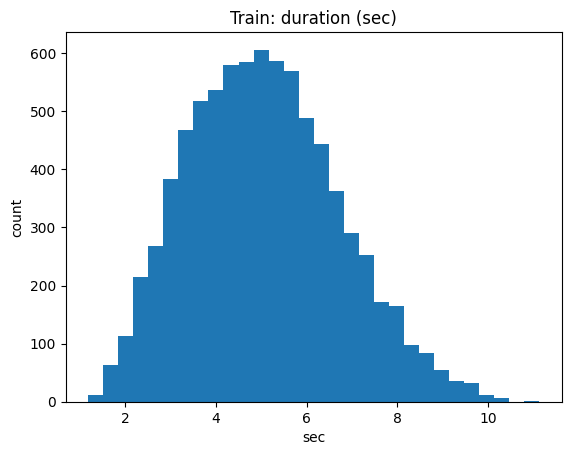

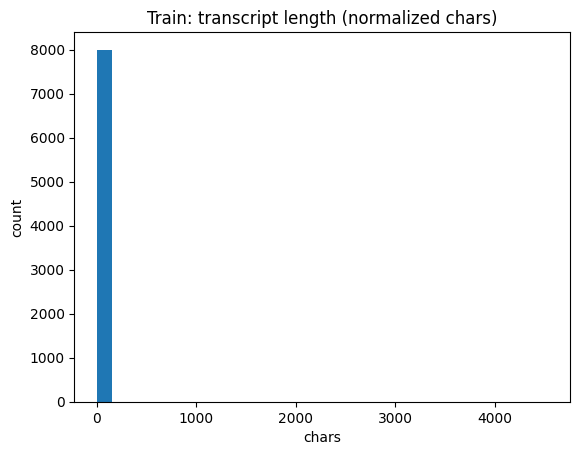

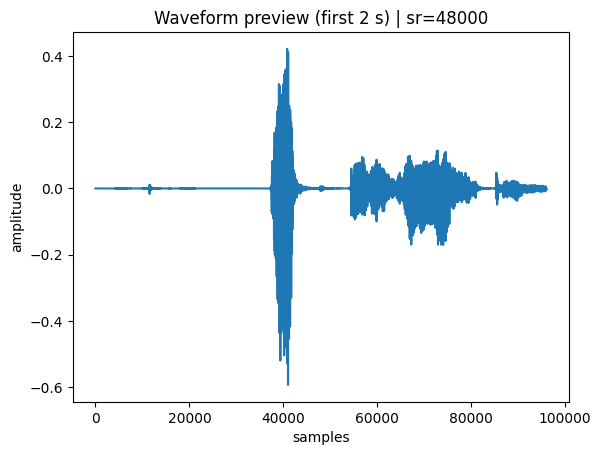

Example transcript: But before I go, I want to tell you a little story.


In [20]:
from collections import Counter

def eda_basic(df_, name):
    print(f"\n--- {name} ---")
    print("N:", len(df_))
    print("Duration mean:", round(df_['duration'].mean(), 3), "p95:", round(df_['duration'].quantile(0.95), 3))
    tl = df_["text_norm"].str.len()
    print("Text len mean:", round(tl.mean(), 2), "p95:", round(tl.quantile(0.95), 2))
    words = Counter(" ".join(df_["text_norm"].tolist()).split())
    print("Top 10 words:", words.most_common(10))

eda_basic(train_df, "TRAIN")
eda_basic(val_df,   "VAL")
eda_basic(test_df,  "TEST")

plt.figure()
plt.hist(train_df["duration"], bins=30)
plt.title("Train: duration (sec)")
plt.xlabel("sec"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(train_df["text_norm"].str.len(), bins=30)
plt.title("Train: transcript length (normalized chars)")
plt.xlabel("chars"); plt.ylabel("count")
plt.show()

# waveform preview
ex_path = train_df.iloc[0]["audio_path"]
wav, sr = torchaudio.load(ex_path)
wav = wav.mean(dim=0) if wav.shape[0] > 1 else wav.squeeze(0)
plt.figure()
plt.plot(wav[: min(len(wav), sr * 2)].numpy())
plt.title(f"Waveform preview (first 2 s) | sr={sr}")
plt.xlabel("samples"); plt.ylabel("amplitude")
plt.show()

print("Example transcript:", train_df.iloc[0]["transcript"])


## 6) Preprocessing (torchaudio decoding) + Torch Dataset
We decode audio ourselves to avoid TorchCodec/FFmpeg. We resample to **16 kHz** and convert to **mono**.


In [21]:
# Audio preprocessing
_resamplers = {}

def trim_silence(wave: torch.Tensor, thr: float = 0.01):
    if wave.numel() < 10:
        return wave
    mask = wave.abs() > thr
    if mask.any():
        i0 = int(mask.argmax())
        i1 = int(len(mask) - mask.flip(0).argmax())
        return wave[i0:i1]
    return wave

def load_audio_16k_mono(path: str, do_trim: bool = False):
    wav, sr = torchaudio.load(path)  # [C, T]
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    wav = wav.squeeze(0)
    if sr != 16000:
        key = (sr, 16000)
        if key not in _resamplers:
            _resamplers[key] = torchaudio.transforms.Resample(sr, 16000)
        wav = _resamplers[key](wav)
    if do_trim:
        wav = trim_silence(wav)
    return wav

class ASRDataset(torch.utils.data.Dataset):
    def __init__(self, df_: pd.DataFrame):
        self.df = df_.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        return {"audio_path": r.audio_path, "text": r.transcript, "text_norm": r.text_norm}

train_ds = ASRDataset(train_df)
val_ds   = ASRDataset(val_df)
test_ds  = ASRDataset(test_df)

print(len(train_ds), len(val_ds), len(test_ds))


8000 600 600


## 7) XLS-R / Wav2Vec2-large model + collator

We use **`facebook/wav2vec2-large-960h-lv60-self`** — a Wav2Vec2-Large model pre-trained on 60 k hours of
unlabelled English audio and fine-tuned on LibriSpeech 960 h with self-training.  
This gives an excellent English baseline (~1.8 % WER on LibriSpeech test-clean) before we even start
fine-tuning on Common Voice en-AU.

The model uses a **CTC head** (no autoregressive decoding), which is much faster to train/evaluate than
Whisper's seq2seq decoder — letting us run more epochs in the same wall-clock time on a P100.


In [22]:
MODEL_NAME = "facebook/wav2vec2-large-960h-lv60-self"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model     = Wav2Vec2ForCTC.from_pretrained(
    MODEL_NAME,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
)

# Freeze the feature encoder — leave transformer layers trainable.
# This is the standard recipe: the CNN feature extractor is already very well
# trained; fine-tuning it wastes GPU time and can hurt generalisation.
model.freeze_feature_encoder()

# Gradient checkpointing for P100 memory efficiency
model.gradient_checkpointing_enable()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")


@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator for CTC. Pads input values and labels independently.
    Labels use -100 for padding so the CTC loss ignores them.
    """
    processor: Wav2Vec2Processor
    do_trim: bool = False
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # ---- audio ----
        audio_arrays = []
        for f in features:
            wav = load_audio_16k_mono(f["audio_path"], do_trim=self.do_trim)
            audio_arrays.append(wav.numpy())

        batch_input = self.processor(
            audio_arrays,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
        )

        # ---- labels (text) ----
        texts = [f["text"].upper() for f in features]  # wav2vec2 vocab is uppercase
        with self.processor.as_target_processor():
            labels_batch = self.processor(
                texts,
                return_tensors="pt",
                padding=True,
            )

        # Replace padding token id with -100 so CTC ignores it
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )

        batch_input["labels"] = labels
        return batch_input


data_collator = DataCollatorCTCWithPadding(processor=processor, do_trim=False)
print("Model ready.")


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/wav2vec2-large-960h-lv60-self were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h-lv60-self and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.maske

Model parameters: 315.47152 M
Trainable parameters: 311.261344 M
Model ready.


## 8) Metrics (WER + CER) — normalized


In [24]:
def normalize_for_metrics(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\[[^\]]*\]", " ", s)
    s = re.sub(r"[^a-z' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids    = np.argmax(pred_logits, axis=-1)

    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str  = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)

    pred_norm  = [normalize_for_metrics(s) for s in pred_str]
    label_norm = [normalize_for_metrics(s) for s in label_str]

    return {
        "wer_norm": jiwer_wer(label_norm, pred_norm),
        "cer_norm": jiwer_cer(label_norm, pred_norm),
    }


## 9) Training (P100-friendly)

### Key hyperparameter choices
| Param | Value | Rationale |
|---|---|---|
| `per_device_train_batch_size` | 4 | Fits P100 16 GB with fp16 + gradient checkpointing |
| `gradient_accumulation_steps` | 4 | Effective batch = 16 |
| `num_train_epochs` | 5 | More epochs → lower WER; CTC trains faster than seq2seq |
| `learning_rate` | 3e-5 | Sweet spot for fine-tuning large wav2vec2 |
| `warmup_steps` | 500 | ~6 % of steps; avoids early instability |
| `mask_time_prob` | 0.05 | Light SpecAugment on time axis (wav2vec2 built-in) |


In [25]:
BATCH_SIZE = 4
GRAD_ACCUM = 4   # effective batch 16
EPOCHS     = 5
LR         = 3e-5

def prune_checkpoints(folder: str, keep_last_n: int = 1):
    if not os.path.isdir(folder):
        return
    cks = [d for d in os.listdir(folder) if d.startswith("checkpoint-")]
    if len(cks) <= keep_last_n:
        return
    cks = sorted(cks, key=lambda x: int(x.split("-")[-1]))
    for ck in cks[:-keep_last_n]:
        shutil.rmtree(os.path.join(folder, ck), ignore_errors=True)


training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_steps=500,
    num_train_epochs=EPOCHS,
    fp16=True,
    gradient_checkpointing=True,
    evaluation_strategy="steps",
    save_strategy="steps",
    eval_steps=250,
    save_steps=250,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="wer_norm",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False,
    # wav2vec2-specific: apply SpecAugment during training
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    tokenizer=processor.feature_extractor,
    compute_metrics=compute_metrics,
)

trainer


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [26]:
print(train_ds[0].keys())
print(train_ds[0])


dict_keys(['audio_path', 'text', 'text_norm'])
{'audio_path': '/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_681249.mp3', 'text': 'But before I go, I want to tell you a little story.', 'text_norm': 'but before i go i want to tell you a little story'}


In [27]:
# 10) Train
train_result = trainer.train()
trainer.save_model(os.path.join(OUTPUT_DIR, "best_model"))
prune_checkpoints(OUTPUT_DIR, keep_last_n=1)
print(train_result)


/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reent

Step,Training Loss,Validation Loss,Wer Norm,Cer Norm
250,0.919500,0.630508,0.246541,0.142099
500,0.479100,0.242887,0.239182,0.139285
750,0.397800,0.236778,0.234619,0.135226
1000,0.388500,0.224019,0.230350,0.134008
1250,0.371400,0.212930,0.232705,0.134576
1500,0.366100,0.203310,0.225787,0.130490
1750,0.359500,0.201050,0.186930,0.103131
2000,0.362800,0.194447,0.152929,0.077531
2250,0.326000,0.190459,0.151016,0.076530
2500,0.356400,0.190358,0.144539,0.071388


/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reent

TrainOutput(global_step=2500, training_loss=0.48875844383239747, metrics={'train_runtime': 6804.9339, 'train_samples_per_second': 5.878, 'train_steps_per_second': 0.367, 'total_flos': 8.252450993404103e+18, 'train_loss': 0.48875844383239747, 'epoch': 5.0})


In [29]:
# 11) Evaluate + export CSV tables
val_metrics  = trainer.evaluate()
test_metrics = trainer.evaluate(test_ds)

print("VAL:",  val_metrics)
print("TEST:", test_metrics)

pd.DataFrame([val_metrics]).to_csv(os.path.join(OUTPUT_DIR, "val_metrics.csv"),  index=False)
pd.DataFrame([test_metrics]).to_csv(os.path.join(OUTPUT_DIR, "test_metrics.csv"), index=False)


/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:157: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call

VAL: {'eval_loss': 0.1903582662343979, 'eval_wer_norm': 0.14453929938180748, 'eval_cer_norm': 0.07138797932508863, 'eval_runtime': 29.6504, 'eval_samples_per_second': 20.236, 'eval_steps_per_second': 5.059, 'epoch': 5.0}
TEST: {'eval_loss': 0.20716960728168488, 'eval_wer_norm': 0.14523314523314523, 'eval_cer_norm': 0.07121154576528675, 'eval_runtime': 29.934, 'eval_samples_per_second': 20.044, 'eval_steps_per_second': 5.011, 'epoch': 5.0}


## 12) Error analysis (export top errors)


In [31]:
def transcribe_subset(df_small: pd.DataFrame, batch_size: int = 4):
    model.eval()
    preds, refs = [], []
    for i in range(0, len(df_small), batch_size):
        chunk = df_small.iloc[i:i + batch_size]
        audio_arrays = [load_audio_16k_mono(p).numpy() for p in chunk.audio_path.tolist()]
        inputs = processor(
            audio_arrays,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
        ).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        pred_ids   = torch.argmax(logits, dim=-1)
        pred_text  = processor.batch_decode(pred_ids)
        preds.extend(pred_text)
        refs.extend(chunk.transcript.tolist())
    return refs, preds


sample_n  = min(80, len(test_df))
sample_df = test_df.sample(sample_n, random_state=SEED).reset_index(drop=True)
refs, preds = transcribe_subset(sample_df, batch_size=4)

err = pd.DataFrame({"reference": refs, "prediction": preds})
err["ref_norm"]          = err["reference"].apply(normalize_for_metrics)
err["pred_norm"]         = err["prediction"].apply(normalize_for_metrics)
err["wer_sentence_norm"] = [
    jiwer_wer([r], [p]) for r, p in zip(err["ref_norm"], err["pred_norm"])
]
err = err.sort_values("wer_sentence_norm", ascending=False)

err.to_csv(os.path.join(OUTPUT_DIR, "error_analysis.csv"), index=False)
err.head(20)


,reference,prediction,ref_norm,pred_norm,wer_sentence_norm
22,The silicon sealant has dried.,THE SILICAN SEALMENT IS DRIED<unk>,the silicon sealant has dried,the silican sealment is dried unk,0.800000
28,Angkor Thom is in the Bayon style.,ANCHOR FORM IS IN THE BAY ONSTAL<unk>,angkor thom is in the bayon style,anchor form is in the bay onstal unk,0.714286
18,A man talks on the phone while sitting at a me...,A MAN TALKED TO THE PHONE WY SITTING IN A MESS...,a man talks on the phone while sitting at a me...,a man talked to the phone wy sitting in a mess...,0.666667
62,The adjective for a phone which undergoes iota...,DIJECTITEFOL AFFARIN WHICH UNDERGOES IOTATION ...,the adjective for a phone which undergoes iota...,dijectitefol affarin which undergoes iotation ...,0.600000
52,"Initially, Scottsbluff Army Airfield was a sat...",INITIALLY<unk> SCOTT'S BLUFF ARMY AIRFIELD WAS...,initially scottsbluff army airfield was a sate...,initially unk scott's bluff army airfield was ...,0.538462
78,Can maths explain everything?,CAN MATS EXPLAIN EVERYTHING<unk>,can maths explain everything,can mats explain everything unk,0.500000
19,"Easy come, easy go.",EASY COME<unk> EASY GO<unk>,easy come easy go,easy come unk easy go unk,0.500000
10,The tomb of Suleiman Chisti was built by the P...,THE TOMB OF SULEMON KISTI<unk> WAS BUILT BY TH...,the tomb of suleiman chisti was built by the p...,the tomb of sulemon kisti unk was built by the...,0.428571
61,The main airport is the Spichenkovo Airport.,THE MAIN AIRPORT IS THE SPITCHING KOVO AIRPORT...,the main airport is the spichenkovo airport,the main airport is the spitching kovo airport...,0.428571
73,"A reply came back, 'Buy vice locally'.",A REPLY CAME BACK<unk> BA VICE NUCLE,a reply came back 'buy vice locally',a reply came back unk ba vice nucle,0.428571


## 13) Inference demo (single file)


In [32]:
def transcribe_file(path: str) -> str:
    wav = load_audio_16k_mono(path)
    inputs = processor(
        wav.numpy(),
        sampling_rate=16000,
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(pred_ids)[0]


example_path = test_df.iloc[0]["audio_path"]
print("Audio:     ", example_path)
print("Reference: ", test_df.iloc[0]["transcript"])
print("Prediction:", transcribe_file(example_path))


Audio:      /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files/common_voice_en_594722.mp3
Reference:  A blond man plays guitar with one other player barely visible out of frame.
Prediction: A BLONDMAN PLAYS GUITAR WITH ONE OTHER PLAYER BARELY VISIBLE OUT OF TRONE<unk>


In [33]:
# 14) Save processor alongside model for easy reload
processor.save_pretrained(os.path.join(OUTPUT_DIR, "best_model"))
print("All outputs saved to", OUTPUT_DIR)
print("Disk usage (MB):", sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, dn, fn in os.walk(OUTPUT_DIR)
    for f in fn
) // (1024 * 1024))


All outputs saved to /kaggle/working/xlsr_commonvoice_local
Disk usage (MB): 4782
